In [5]:
"""
Назначение файла: быстрый просмотр собранных Bitcoin-данных.
Основные шаги: загрузка processed CSV, просмотр форм таблиц и базовых статистик.
Зависимости или источники данных: data/processed/parsed_txs_features_named.csv, parsed_txs_edgelist.csv, parsed_txs_classes.csv.
"""

'\nНазначение файла: быстрый просмотр собранных Bitcoin-данных.\nОсновные шаги: загрузка processed CSV, просмотр форм таблиц и базовых статистик.\nЗависимости или источники данных: data/processed/parsed_txs_features_named.csv, parsed_txs_edgelist.csv, parsed_txs_classes.csv.\n'

# Preview collected data

Ноутбук показывает базовую проверку файлов, созданных скриптом `scripts/build_dataset.py`.

In [6]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

features_path = PROCESSED_DIR / "parsed_txs_features_named.csv"
edges_path = PROCESSED_DIR / "parsed_txs_edgelist.csv"
classes_path = PROCESSED_DIR / "parsed_txs_classes.csv"

features = pd.read_csv(features_path) if features_path.exists() else pd.DataFrame()
edges = pd.read_csv(edges_path) if edges_path.exists() else pd.DataFrame()
classes = pd.read_csv(classes_path) if classes_path.exists() else pd.DataFrame()

print(f"Features rows {len(features)}")
print(f"Edges rows {len(edges)}")
print(f"Classes rows {len(classes)}")

Features rows 9841
Edges rows 0
Classes rows 9841


In [7]:
features.head()

,tx_hash,time_step,block_height,timestamp,input_count,output_count,total_input_value,total_output_value,fee,fee_rate,...,weak_component_size,num_unique_input_addresses,num_unique_output_addresses,has_many_inputs,has_many_outputs,has_high_fee,has_small_outputs,avg_neighbor_fee,avg_neighbor_total_output_value,sum_neighbor_total_output_value
0,0001f3422f5726ffc6e70021b84a7579606dfe2e633e8d...,1,948666,1778358142,1,1,0.000012,0.000005,6.400000e-06,1.729730e-08,...,1,1.0,1.0,0,0,0,1,0.0,0.0,0.0
1,0009a6000220c39b47a8ea6c2a9d2ea98536ba7a536b84...,1,948666,1778358142,1,2,0.000278,0.000271,7.880000e-06,1.907990e-08,...,1,1.0,2.0,0,0,0,1,0.0,0.0,0.0
2,000b2f58f5e50f1126353ce7d3aa2300890f239a59724c...,1,948666,1778358142,2,1,0.018327,0.018313,1.448000e-05,4.221574e-08,...,1,1.0,1.0,0,0,0,0,0.0,0.0,0.0
3,00383958c81b877478bb0ce0305c2006f91c347f84963d...,1,948666,1778358142,1,2,0.000948,0.000942,5.510000e-06,2.344681e-08,...,1,1.0,2.0,0,0,0,1,0.0,0.0,0.0
4,003e56c0679dcd709c0f6a300acaa9e74312f5c2e3182a...,1,948666,1778358142,1,2,0.000976,0.000976,3.200000e-07,1.447964e-09,...,1,1.0,1.0,0,0,0,1,0.0,0.0,0.0


In [8]:
features['time_step'].value_counts()

time_step
1    9841
Name: count, dtype: int64

## Быстрые визуализации

Графики ниже строятся на ограниченной выборке, чтобы ноутбук быстро открывался даже после сбора большого числа блоков.

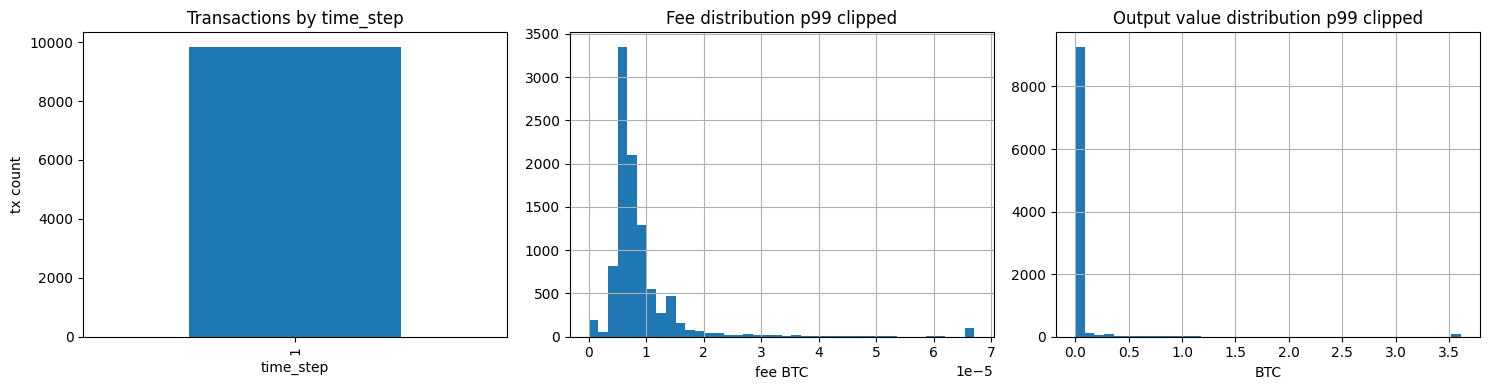

In [9]:
import matplotlib.pyplot as plt

if features.empty:
    print("Файл features пустой или не найден")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    features["time_step"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
    axes[0].set_title("Transactions by time_step")
    axes[0].set_xlabel("time_step")
    axes[0].set_ylabel("tx count")

    features["fee"].clip(upper=features["fee"].quantile(0.99)).hist(bins=40, ax=axes[1])
    axes[1].set_title("Fee distribution p99 clipped")
    axes[1].set_xlabel("fee BTC")

    features["total_output_value"].clip(
        upper=features["total_output_value"].quantile(0.99)
    ).hist(bins=40, ax=axes[2])
    axes[2].set_title("Output value distribution p99 clipped")
    axes[2].set_xlabel("BTC")

    plt.tight_layout()

In [10]:
import networkx as nx

MAX_EDGES = 50

if edges.empty:
    print("Edge list пустой. Пересоберите датасет после обновления parser.py: python scripts\\build_dataset.py --time-window-hours 1")
else:
    sample_edges = edges.head(MAX_EDGES).copy()
    graph = nx.from_pandas_edgelist(
        sample_edges,
        source="txId1",
        target="txId2",
        create_using=nx.DiGraph(),
    )

    node_values = features.set_index("tx_hash")["total_output_value"].to_dict()
    edge_labels = {}
    for source, target in graph.edges():
        weight = float(node_values.get(target, 0.0))
        graph[source][target]["weight"] = weight
        edge_labels[(source, target)] = f"{weight:.4f}"

    plt.figure(figsize=(14, 9))
    pos = nx.spring_layout(graph, seed=42, k=0.8)
    node_sizes = [300 + 3000 * min(node_values.get(node, 0.0), 0.05) for node in graph.nodes()]
    labels = {node: str(node)[:8] for node in graph.nodes()}

    nx.draw_networkx_nodes(graph, pos, node_size=node_sizes, alpha=0.85)
    nx.draw_networkx_edges(graph, pos, arrows=True, alpha=0.35, width=1.2)
    nx.draw_networkx_labels(graph, pos, labels=labels, font_size=8)
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=7)
    plt.title(f"Transaction graph sample, edges {len(sample_edges)}")
    plt.axis("off")
    plt.show()

Edge list пустой. Пересоберите датасет после обновления parser.py: python scripts\build_dataset.py --time-window-hours 1


In [11]:
edges.head()

,txId1,txId2


# как работать с парсером
cd ..
python -m venv .venv
.venv\Scripts\activate
pip install -r requirements.txt

python scripts\collect_blocks.py --max-blocks 2
python scripts\build_dataset.py --time-window-hours 1